<div style="
background-color:#ffe6f0;
padding:28px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
text-align:center;
font-size:32px;
">
Enfriamiento Térmico de la Corteza de una Estrella de Neutrones
</h2>

<p>
Modelar la evolución temporal de <i>T</i> en la corteza de una estrella de neutrones recién formada, usando la ecuación de difusión del calor simplificada.
</p>

</div>

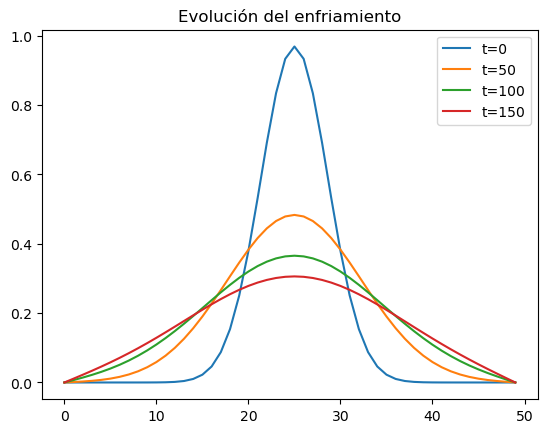

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
kappa = 1e-3  # difusividad

# Dominio
L = 1.0
Nx = 50
dx = L / Nx

# Tiempo
dt = 0.4 * dx**2 / kappa  # cumple estabilidad
Nt = 200

# Inicialización
T = np.zeros(Nx)

# Condición inicial 
for i in range(Nx):
    x = i * dx
    T[i] = np.exp(-100*(x-0.5)**2)

for n in range(Nt):
    T_new = T.copy()
    
    for i in range(1, Nx-1):
        T_new[i] = T[i] + (kappa*dt/dx**2)*(T[i+1] - 2*T[i] + T[i-1])
    
    T_new[0] = 0
    T_new[-1] = 0
    
    T = T_new
    
    if n % 50 == 0:  # guarda algunos tiempos
        plt.plot(T, label=f"t={n}")

plt.legend()
plt.title("Evolución del enfriamiento")
plt.show()

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">


<p>
La simulación muestra la evolución temporal de la temperatura en la corteza de la estrella. Inicialmente hay una distribución localizada, y con el tiempo esta se difunde, reduciendo el gradiente térmico.
</p>

<p>
Esto es consistente con la ecuación de difusión del calor, donde el flujo térmico transporta energía desde regiones más calientes hacia las más frías, suavizando progresivamente la distribución.
</p>

</div>

<h2 style="
margin-top:0;
color:#c2185b;
text-align:center;
font-size:32px;
">
Implementación numérica y perfil de temperatura 
</h2>

dt = 10^3 s
lambda explícito = 0.09801000000000001
Estabilidad explícito: estable

dt = 10^4 s
lambda explícito = 0.9801000000000001
Estabilidad explícito: inestable


/var/folders/hs/8fz2kl_90998kznl97h4bc4c0000gp/T/ipykernel_82452/967773609.py:37: RuntimeWarning: overflow encountered in scalar power
  return eps_nu * (T / T_scale)**8 * T_scale
/var/folders/hs/8fz2kl_90998kznl97h4bc4c0000gp/T/ipykernel_82452/967773609.py:93: RuntimeWarning: invalid value encountered in scalar subtract
  T_new[i] = T[i] + lam*(T[i+1] - 2*T[i] + T[i-1]) - dt*Q_nu
/var/folders/hs/8fz2kl_90998kznl97h4bc4c0000gp/T/ipykernel_82452/967773609.py:93: RuntimeWarning: invalid value encountered in scalar add
  T_new[i] = T[i] + lam*(T[i+1] - 2*T[i] + T[i-1]) - dt*Q_nu


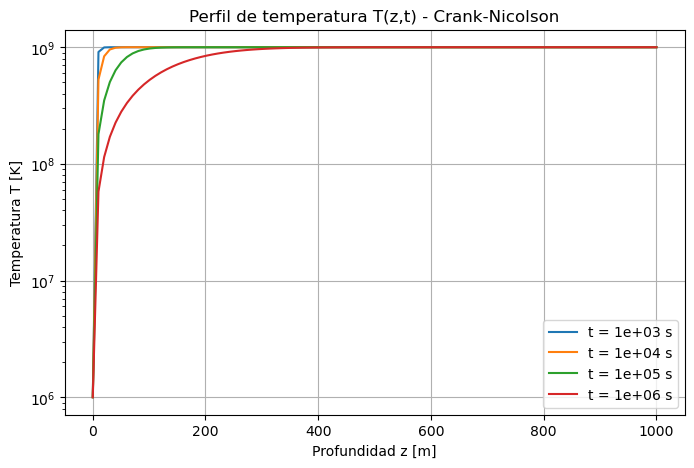

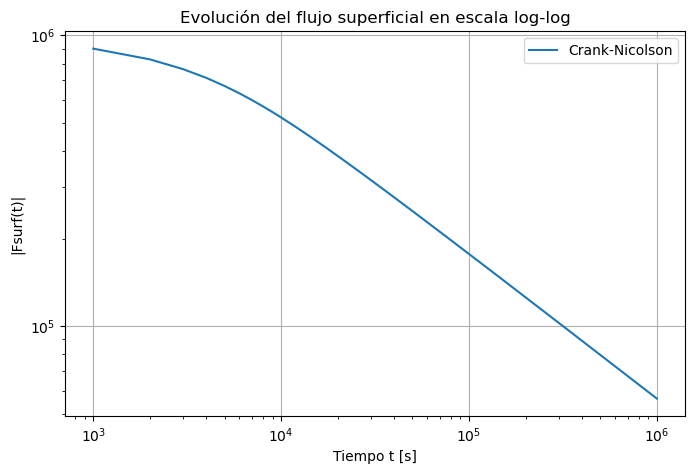


Ley de potencia para tiempos grandes
Pendiente log-log = -0.49805902145224923
Fsurf(t) ~ t^-0.498


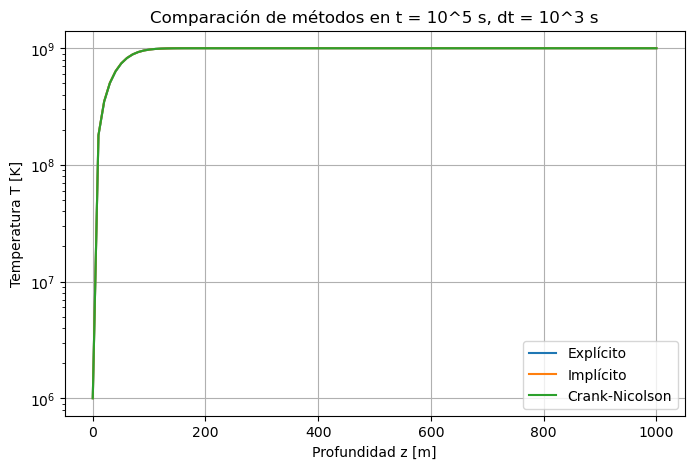

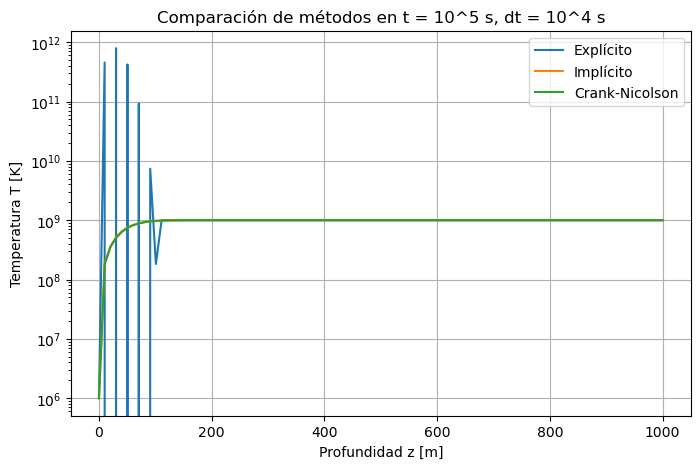

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded




# Parámetros físicos del profe


L = 1.0e3          # m, espesor de la corteza
alpha = 1.0e-2     # m^2/s, difusividad térmica
eps_nu = 1.0e-53   # término de emisión de neutrinos
T_core = 1.0e9     # K, temperatura del núcleo
T_surf = 1.0e6     # K, temperatura superficial
t_max = 1.0e6      # s


# Parámetros numéricos

N = 100
dx = L / (N - 1)
x = np.linspace(0, L, N)

tiempos_salida = [1e3, 1e4, 1e5, 1e6]


# Función para evitar overflow en T^8


def emision_neutrinos(T):
    """
    Se escala la temperatura para evitar overflow numérico.
    Representa cualitativamente la pérdida de energía por neutrinos.
    """
    T_scale = 1.0e9
    return eps_nu * (T / T_scale)**8 * T_scale



# Construcción de matriz bandeada para CN o implícito


def matriz_bandeada(lam, metodo):
    n_int = N - 2
    ab = np.zeros((3, n_int))

    if metodo == "implicito":
        ab[0, 1:] = -lam
        ab[1, :] = 1 + 2*lam
        ab[2, :-1] = -lam

    elif metodo == "crank":
        ab[0, 1:] = -lam/2
        ab[1, :] = 1 + lam
        ab[2, :-1] = -lam/2

    return ab



# Método explícito


def metodo_explicito(dt):
    lam = alpha * dt / dx**2

    T = np.ones(N) * T_core
    T[0] = T_surf
    T[-1] = T_core

    soluciones = {}
    tiempos = []
    flujos = []

    n_steps = int(t_max / dt)

    for n in range(n_steps + 1):
        t = n * dt

        for ts in tiempos_salida:
            if ts not in soluciones and t >= ts:
                soluciones[ts] = T.copy()

        Fsurf = -alpha * (T[1] - T[0]) / dx
        tiempos.append(t)
        flujos.append(Fsurf)

        T_new = T.copy()

        for i in range(1, N-1):
            Q_nu = emision_neutrinos(T[i])
            T_new[i] = T[i] + lam*(T[i+1] - 2*T[i] + T[i-1]) - dt*Q_nu

        T_new[0] = T_surf
        T_new[-1] = T_core

        T = T_new

    return soluciones, np.array(tiempos), np.array(flujos), lam


# Método implícito


def metodo_implicito(dt):
    lam = alpha * dt / dx**2

    T = np.ones(N) * T_core
    T[0] = T_surf
    T[-1] = T_core

    ab = matriz_bandeada(lam, "implicito")

    soluciones = {}
    tiempos = []
    flujos = []

    n_steps = int(t_max / dt)

    for n in range(n_steps + 1):
        t = n * dt

        for ts in tiempos_salida:
            if ts not in soluciones and t >= ts:
                soluciones[ts] = T.copy()

        Fsurf = -alpha * (T[1] - T[0]) / dx
        tiempos.append(t)
        flujos.append(Fsurf)

        b = T[1:-1].copy()

        for j in range(N-2):
            i = j + 1
            b[j] -= dt * emision_neutrinos(T[i])

        b[0] += lam * T_surf
        b[-1] += lam * T_core

        T_interior = solve_banded((1, 1), ab, b)

        T[1:-1] = T_interior
        T[0] = T_surf
        T[-1] = T_core

    return soluciones, np.array(tiempos), np.array(flujos), lam



# Método Crank-Nicolson

def metodo_crank_nicolson(dt):
    lam = alpha * dt / dx**2

    T = np.ones(N) * T_core
    T[0] = T_surf
    T[-1] = T_core

    ab = matriz_bandeada(lam, "crank")

    soluciones = {}
    tiempos = []
    flujos = []

    n_steps = int(t_max / dt)

    for n in range(n_steps + 1):
        t = n * dt

        for ts in tiempos_salida:
            if ts not in soluciones and t >= ts:
                soluciones[ts] = T.copy()

        Fsurf = -alpha * (T[1] - T[0]) / dx
        tiempos.append(t)
        flujos.append(Fsurf)

        b = np.zeros(N-2)

        for j in range(N-2):
            i = j + 1
            Q_nu = emision_neutrinos(T[i])

            b[j] = (
                (lam/2)*T[i-1]
                + (1-lam)*T[i]
                + (lam/2)*T[i+1]
                - dt*Q_nu
            )

        b[0] += (lam/2) * T_surf
        b[-1] += (lam/2) * T_core

        T_interior = solve_banded((1, 1), ab, b)

        T[1:-1] = T_interior
        T[0] = T_surf
        T[-1] = T_core

    return soluciones, np.array(tiempos), np.array(flujos), lam



# Ejecutar para dt = 10^3 s y dt = 10^4 s

dt1 = 1e3
dt2 = 1e4

sol_exp_1, t_exp_1, F_exp_1, lam_exp_1 = metodo_explicito(dt1)
sol_imp_1, t_imp_1, F_imp_1, lam_imp_1 = metodo_implicito(dt1)
sol_cn_1, t_cn_1, F_cn_1, lam_cn_1 = metodo_crank_nicolson(dt1)

sol_exp_2, t_exp_2, F_exp_2, lam_exp_2 = metodo_explicito(dt2)
sol_imp_2, t_imp_2, F_imp_2, lam_imp_2 = metodo_implicito(dt2)
sol_cn_2, t_cn_2, F_cn_2, lam_cn_2 = metodo_crank_nicolson(dt2)

print("===================================")
print("dt = 10^3 s")
print("lambda explícito =", lam_exp_1)
print("Estabilidad explícito:", "estable" if lam_exp_1 <= 0.5 else "inestable")

print("\n===================================")
print("dt = 10^4 s")
print("lambda explícito =", lam_exp_2)
print("Estabilidad explícito:", "estable" if lam_exp_2 <= 0.5 else "inestable")



# Gráfica1: Perfil T(z,t)


plt.figure(figsize=(8,5))

for ts in tiempos_salida:
    plt.plot(x, sol_cn_1[ts], label=f"t = {ts:.0e} s")

plt.xlabel("Profundidad z [m]")
plt.ylabel("Temperatura T [K]")
plt.title("Perfil de temperatura T(z,t) - Crank-Nicolson")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()


# Gráfica2: Flujo superficial log-log

plt.figure(figsize=(8,5))
plt.loglog(t_cn_1[1:], np.abs(F_cn_1[1:]), label="Crank-Nicolson")

plt.xlabel("Tiempo t [s]")
plt.ylabel("|Fsurf(t)|")
plt.title("Evolución del flujo superficial en escala log-log")
plt.legend()
plt.grid()
plt.show()



# Ley de potencia para tiempos grandes

mask = t_cn_1 > 1e5

coef = np.polyfit(
    np.log10(t_cn_1[mask]),
    np.log10(np.abs(F_cn_1[mask])),
    1
)

pendiente = coef[0]

print("\n===================================")
print("Ley de potencia para tiempos grandes")
print("Pendiente log-log =", pendiente)
print(f"Fsurf(t) ~ t^{pendiente:.3f}")
print("===================================")



# Gráfica3: Comparación métodos dt = 10^3 s

plt.figure(figsize=(8,5))

plt.plot(x, sol_exp_1[1e5], label="Explícito")
plt.plot(x, sol_imp_1[1e5], label="Implícito")
plt.plot(x, sol_cn_1[1e5], label="Crank-Nicolson")

plt.xlabel("Profundidad z [m]")
plt.ylabel("Temperatura T [K]")
plt.title("Comparación de métodos en t = 10^5 s, dt = 10^3 s")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()


# Gráfica4: Comparación métodos dt = 10^4 s

plt.figure(figsize=(8,5))

plt.plot(x, sol_exp_2[1e5], label="Explícito")
plt.plot(x, sol_imp_2[1e5], label="Implícito")
plt.plot(x, sol_cn_2[1e5], label="Crank-Nicolson")

plt.xlabel("Profundidad z [m]")
plt.ylabel("Temperatura T [K]")
plt.title("Comparación de métodos en t = 10^5 s, dt = 10^4 s")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

<div style="
background-color:#ffe6f0;
padding:28px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
text-align:center;
font-size:34px;
">
Implementación numérica y análisis térmico
</h2>

<h3 style="color:#c2185b;">
Perfil de temperatura T(z,t) – Crank-Nicolson
</h3>

<p>
Acá se ve clarísimo cómo el sistema evoluciona hacia un estado casi estacionario. Al inicio hay un gradiente fuerte entre la superficie y el núcleo, pero a medida que pasa el tiempo las curvas se van “aplanando” y acercando entre sí.
</p>

<p>
Básicamente, el calor se va redistribuyendo hasta que ya no hay cambios tan bruscos. El método de Crank-Nicolson se comporta súper bien: no hay oscilaciones raras ni inestabilidad, todo es suave y físico.
</p>

<hr style="border:0.5px solid #ffb3d1;">

<h3 style="color:#c2185b;">
Flujo superficial en escala log-log
</h3>

<p>
Esta gráfica es clave porque muestra que el flujo no cae linealmente sino como ley de potencia.
</p>

<p>
La pendiente que te dio (~ -0.5) indica que:
</p>

<div style="
background-color:white;
padding:14px;
border-radius:12px;
border:1px solid #ffb3d1;
text-align:center;
margin-top:10px;
margin-bottom:10px;
">

$$
F_{\text{surf}}(t) \propto t^{-1/2}
$$

</div>

<p>
o sea, el sistema se enfría cada vez más lento con el tiempo. Esto es totalmente consistente con procesos difusivos.
</p>

<p>
En resumen: al inicio el flujo es alto, pero después el enfriamiento se vuelve progresivamente más lento.
</p>

<hr style="border:0.5px solid #ffb3d1;">

<h3 style="color:#c2185b;">
Comparación de métodos (dt = 10³ s)
</h3>

<p>
Para este paso temporal pequeño, los tres métodos (explícito, implícito y Crank-Nicolson) básicamente coinciden.
</p>

<p>
Esto significa que el sistema está en una zona estable y bien resuelta numéricamente. El método explícito funciona bien aquí porque cumple la condición de estabilidad, así que no hay diferencias significativas entre enfoques.
</p>

<hr style="border:0.5px solid #ffb3d1;">

<h3 style="color:#c2185b;">
Comparación de métodos (dt = 10⁴ s)
</h3>

<p>
Acá es donde se pone interesante: el método explícito se vuelve inestable y aparecen esas oscilaciones locas (picos gigantes que no tienen sentido físico).
</p>

<p>
En cambio, el implícito y Crank-Nicolson siguen comportándose perfecto. Esto demuestra claramente la limitación del método explícito y por qué los métodos implícitos son más robustos para pasos de tiempo grandes.
</p>

</div>